# Binary Relevance Mental-BERT untuk Dataset Consulife

Notebook ini membangun tiga target biner independen untuk strategi **Binary Relevance** pada label `Stress`, `Anxiety`, dan `Depression`.

Default training pada notebook ini difokuskan ke model **Depression**, sesuai kebutuhan untuk menangani imbalance ekstrem. Jika ingin melatih semua label, gunakan sel opsional di bagian akhir.

## 1. Import Library dan Konfigurasi

Jika package belum tersedia, jalankan instalasi berikut di terminal atau buka komentar pada baris `pip install`.

In [1]:
%uv pip install -r requirements.txt

Using Python 3.12.6 environment at: /usr/local
Resolved 69 packages in 399ms
⠙ Preparing packages... (0/8)
⠙ Preparing packages... (0/8)
et-xmlfile ------------------------------     0 B/17.64 KiB
⠙ Preparing packages... (0/8)
et-xmlfile ------------------------------ 14.84 KiB/17.64 KiB
⠙ Preparing packages... (0/8)
et-xmlfile ------------------------------ 14.84 KiB/17.64 KiB
dill       ------------------------------     0 B/117.21 KiB
⠙ Preparing packages... (0/8)
et-xmlfile ------------------------------ 14.84 KiB/17.64 KiB
dill       ------------------------------ 16.00 KiB/117.21 KiB
⠙ Preparing packages... (0/8)
et-xmlfile ------------------------------ 14.84 KiB/17.64 KiB
dill       ------------------------------ 16.00 KiB/117.21 KiB
⠙ Preparing packages... (0/8)
et-xmlfile ------------------------------ 14.84 KiB/17.64 KiB
dill       ------------------------------ 16.00 KiB/117.21 KiB
xxhash     ------------------------------ 14.87 KiB/215.30 KiB
⠙ Preparing packages... (0/8)


In [ ]:
# !
import random
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import f1_score
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import os
os.environ["HF_TOKEN"] = "your_hf_token"

In [31]:
TEXT_COLUMN = "Complaint"
LABEL_COLUMNS = ["Stress", "Anxiety", "Depression"]

DATA_PATH = "New_Consulife_Dataset.xlsx"
MODEL_NAME = "mental/mental-bert-base-uncased"
OUTPUT_DIR = "binary_relevance_mentalbert_models_oversampling"

SEED = 42
MAX_LENGTH = 256
BATCH_SIZE = 8
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [32]:
def set_seed(seed: int) -> None:
    """Membuat eksperimen lebih reproducible."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

## 2. Load Data dan Buat Kolom Multilabel

File `Consulife_Dataset_English.csv` memakai delimiter titik koma (`;`). Fungsi di bawah memakai autodetect delimiter agar tetap aman untuk CSV comma atau semicolon.

In [33]:
def load_dataset(path: str | Path) -> pd.DataFrame:
    """Load CSV/XLSX, validasi kolom, dan buat kolom list multilabel."""

    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File tidak ditemukan: {path}")

    if path.suffix.lower() in {".xlsx", ".xls"}:
        df = pd.read_excel(path)
    else:
        df = pd.read_csv(path, sep=None, engine="python")

    required_columns = [TEXT_COLUMN, *LABEL_COLUMNS]
    missing_columns = [column for column in required_columns if column not in df.columns]
    if missing_columns:
        raise ValueError(f"Kolom berikut tidak ditemukan: {missing_columns}")

    df = df[required_columns].copy()
    df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna("").astype(str)

    for column in LABEL_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce").fillna(0).astype(int)
        invalid_values = sorted(set(df[column].unique()) - {0, 1})
        if invalid_values:
            raise ValueError(f"Kolom {column} memiliki nilai non-biner: {invalid_values}")

    # Format multilabel: [Stress, Anxiety, Depression]
    df["labels"] = df[LABEL_COLUMNS].values.astype(int).tolist()
    return df


df = load_dataset(DATA_PATH)
print(df.shape)
df.head()

(894, 5)


,Complaint,Stress,Anxiety,Depression,labels
0,The problem of staknancy with thesis and confu...,1,0,0,"[1, 0, 0]"
1,"Lately, I feel stress and feelings of fear tha...",1,1,0,"[1, 1, 0]"
2,"Like deg, suddenly want to cry",0,1,0,"[0, 1, 0]"
3,"Actually, I feel that I don't have any mental ...",1,1,0,"[1, 1, 0]"
4,"Feeling stuck, difficult to focus on things th...",1,0,1,"[1, 0, 1]"


## 3. Multilabel Stratified Split 70/15/15

Split dilakukan dua tahap:

1. Train 70% dan temporary 30%.
2. Temporary 30% dibagi menjadi validation 15% dan test 15%.

In [34]:
@dataclass
class SplitData:
    train_df: pd.DataFrame
    val_df: pd.DataFrame
    test_df: pd.DataFrame


def multilabel_train_val_test_split(
    df: pd.DataFrame,
    seed: int = 42,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
) -> SplitData:
    """Split 70/15/15 dengan MultilabelStratifiedShuffleSplit."""

    total = train_size + val_size + test_size
    if not np.isclose(total, 1.0):
        raise ValueError("train_size + val_size + test_size harus sama dengan 1.0")

    x_indices = np.arange(len(df))
    y_multilabel = np.vstack(df["labels"].to_numpy()).astype(int)

    first_splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=(1.0 - train_size),
        random_state=seed,
    )
    train_idx, temp_idx = next(first_splitter.split(x_indices, y_multilabel))

    temp_df = df.iloc[temp_idx].reset_index(drop=True)
    temp_y = np.vstack(temp_df["labels"].to_numpy()).astype(int)
    temp_indices = np.arange(len(temp_df))

    relative_test_size = test_size / (val_size + test_size)
    second_splitter = MultilabelStratifiedShuffleSplit(
        n_splits=1,
        test_size=relative_test_size,
        random_state=seed,
    )
    val_idx, test_idx = next(second_splitter.split(temp_indices, temp_y))

    return SplitData(
        train_df=df.iloc[train_idx].reset_index(drop=True),
        val_df=temp_df.iloc[val_idx].reset_index(drop=True),
        test_df=temp_df.iloc[test_idx].reset_index(drop=True),
    )


def print_split_report(split_data: SplitData) -> None:
    """Menampilkan distribusi positif tiap label pada setiap split."""

    for split_name, split_df in [
        ("Train", split_data.train_df),
        ("Validation", split_data.val_df),
        ("Test", split_data.test_df),
    ]:
        counts = split_df[LABEL_COLUMNS].sum().astype(int).to_dict()
        print(f"{split_name:10s} n={len(split_df):4d} | positives={counts}")


split_data = multilabel_train_val_test_split(df, seed=SEED)
print_split_report(split_data)

Train      n= 625 | positives={'Stress': 449, 'Anxiety': 401, 'Depression': 214}
Validation n= 134 | positives={'Stress': 96, 'Anxiety': 86, 'Depression': 46}
Test       n= 135 | positives={'Stress': 97, 'Anxiety': 86, 'Depression': 46}


## 4. Pisahkan Target Binary Relevance

Masing-masing model hanya mengambil satu indeks dari target multilabel:

- Model Stress: indeks 0.
- Model Anxiety: indeks 1.
- Model Depression: indeks 2.

In [35]:
def extract_binary_targets(df: pd.DataFrame) -> Dict[str, np.ndarray]:
    """Memecah list target [Stress, Anxiety, Depression] menjadi target independen."""

    y = np.vstack(df["labels"].to_numpy()).astype(int)
    return {
        "Stress": y[:, 0],
        "Anxiety": y[:, 1],
        "Depression": y[:, 2],
    }


train_targets = extract_binary_targets(split_data.train_df)
val_targets = extract_binary_targets(split_data.val_df)
test_targets = extract_binary_targets(split_data.test_df)

for label_name in LABEL_COLUMNS:
    print(label_name)
    print("  train:", np.bincount(train_targets[label_name], minlength=2))
    print("  val  :", np.bincount(val_targets[label_name], minlength=2))
    print("  test :", np.bincount(test_targets[label_name], minlength=2))

Stress
  train: [176 449]
  val  : [38 96]
  test : [38 97]
Anxiety
  train: [224 401]
  val  : [48 86]
  test : [49 86]
Depression
  train: [411 214]
  val  : [88 46]
  test : [89 46]


## 5. Hitung `pos_weight` per Label

`pos_weight = jumlah kelas negatif / jumlah kelas positif` dihitung hanya dari data train untuk mencegah data leakage.

In [36]:
def compute_pos_weight(y_train: np.ndarray) -> torch.Tensor:
    """Menghitung pos_weight untuk BCEWithLogitsLoss."""

    positive_count = float(np.sum(y_train == 1))
    negative_count = float(np.sum(y_train == 0))

    if positive_count == 0:
        raise ValueError("Data train tidak memiliki sampel positif untuk label ini.")

    return torch.tensor([negative_count / positive_count], dtype=torch.float32)


pos_weights = {label: compute_pos_weight(train_targets[label]) for label in LABEL_COLUMNS}

for label_name, weight in pos_weights.items():
    print(f"{label_name:10s}: pos_weight = {weight.item():.4f}")

Stress    : pos_weight = 0.3920
Anxiety   : pos_weight = 0.5586
Depression: pos_weight = 1.9206


## 6. Dataset dan DataLoader PyTorch

Setiap item menghasilkan token BERT dan satu label biner berbentuk float, sesuai kebutuhan `BCEWithLogitsLoss`.

In [37]:
class BinaryComplaintDataset(Dataset):
    """Dataset PyTorch untuk satu target biner dari strategi Binary Relevance."""

    def __init__(
        self,
        texts: Iterable[str],
        labels: Iterable[int],
        tokenizer: AutoTokenizer,
        max_length: int = 256,
    ) -> None:
        self.texts = list(texts)
        self.labels = torch.tensor(list(labels), dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        encoded = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {key: value.squeeze(0) for key, value in encoded.items()}
        item["labels"] = self.labels[idx]
        return item


def build_dataloader(
    df: pd.DataFrame,
    labels: np.ndarray,
    tokenizer: AutoTokenizer,
    batch_size: int,
    max_length: int,
    shuffle: bool,
) -> DataLoader:
    dataset = BinaryComplaintDataset(
        texts=df[TEXT_COLUMN].tolist(),
        labels=labels.tolist(),
        tokenizer=tokenizer,
        max_length=max_length,
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

## 7. Training dan Evaluation Loop

Model memakai `num_labels=1`, sehingga output classifier adalah satu logit. Probabilitas dihitung dengan sigmoid, lalu threshold default `0.5` dipakai untuk F1 biner.

In [38]:
def run_epoch(
    model: AutoModelForSequenceClassification,
    dataloader: DataLoader,
    criterion: torch.nn.Module,
    device: torch.device,
    optimizer: torch.optim.Optimizer | None = None,
    scheduler: torch.optim.lr_scheduler.LRScheduler | None = None,
    progress_desc: str | None = None,
) -> Tuple[float, float]:
    """Menjalankan satu epoch train/eval dan mengembalikan loss rata-rata serta F1."""

    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_predictions: List[int] = []
    all_targets: List[int] = []

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        iterator = tqdm(dataloader, desc=progress_desc, leave=False) if progress_desc else dataloader
        for batch in iterator:
            labels = batch.pop("labels").to(device)
            batch = {key: value.to(device) for key, value in batch.items()}

            outputs = model(**batch)
            logits = outputs.logits.squeeze(-1)
            loss = criterion(logits, labels)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()

            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long().detach().cpu().numpy()

            total_loss += loss.item() * labels.size(0)
            all_predictions.extend(predictions.tolist())
            all_targets.extend(labels.detach().cpu().numpy().astype(int).tolist())

    average_loss = total_loss / len(dataloader.dataset)
    binary_f1 = f1_score(all_targets, all_predictions, average="binary", zero_division=0)
    return average_loss, binary_f1

In [39]:
def train_binary_model(
    target_label: str,
    split_data: SplitData,
    train_targets: Dict[str, np.ndarray],
    val_targets: Dict[str, np.ndarray],
    test_targets: Dict[str, np.ndarray],
    model_name: str = MODEL_NAME,
    output_dir: str | Path = OUTPUT_DIR,
    batch_size: int = BATCH_SIZE,
    max_length: int = MAX_LENGTH,
    epochs: int = EPOCHS,
    learning_rate: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
) -> None:
    """Melatih satu model biner independen untuk satu label target."""

    label_output_dir = Path(output_dir) / target_label.lower()
    label_output_dir.mkdir(parents=True, exist_ok=True)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=1,
        ignore_mismatched_sizes=True,
    ).to(device)

    train_loader = build_dataloader(
        split_data.train_df,
        train_targets[target_label],
        tokenizer,
        batch_size=batch_size,
        max_length=max_length,
        shuffle=True,
    )
    val_loader = build_dataloader(
        split_data.val_df,
        val_targets[target_label],
        tokenizer,
        batch_size=batch_size,
        max_length=max_length,
        shuffle=False,
    )
    test_loader = build_dataloader(
        split_data.test_df,
        test_targets[target_label],
        tokenizer,
        batch_size=batch_size,
        max_length=max_length,
        shuffle=False,
    )

    pos_weight = compute_pos_weight(train_targets[target_label]).to(device)
    criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    total_training_steps = epochs * len(train_loader)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_training_steps),
        num_training_steps=total_training_steps,
    )

    print(f"Training binary model: {target_label}")
    print(f"Device: {device}")
    print(f"Train positives: {int(train_targets[target_label].sum())}")
    print(f"Train negatives: {int((train_targets[target_label] == 0).sum())}")
    print(f"pos_weight: {pos_weight.item():.4f}")

    best_val_f1 = -1.0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs} [{target_label}]")

        train_loss, train_f1 = run_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            device=device,
            optimizer=optimizer,
            scheduler=scheduler,
            progress_desc="Train",
        )
        val_loss, val_f1 = run_epoch(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            device=device,
            progress_desc="Validation",
        )

        print(
            f"Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f}"
        )

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            model.save_pretrained(label_output_dir)
            tokenizer.save_pretrained(label_output_dir)
            print(f"Saved best checkpoint to: {label_output_dir}")

    best_model = AutoModelForSequenceClassification.from_pretrained(label_output_dir).to(device)
    test_loss, test_f1 = run_epoch(
        model=best_model,
        dataloader=test_loader,
        criterion=criterion,
        device=device,
    )
    print(
        f"\nBest epoch: {best_epoch} | Best Val F1: {best_val_f1:.4f} | "
        f"Test Loss: {test_loss:.4f} | Test F1: {test_f1:.4f}"
    )

## 8. Training Model Depression

Sel berikut melatih model Binary Relevance khusus label `Depression`. Ini adalah model yang paling relevan saat imbalance pada kelas Depression menjadi fokus utama.

In [14]:
train_binary_model(
    target_label="Stress",
    split_data=split_data,
    train_targets=train_targets,
    val_targets=val_targets,
    test_targets=test_targets,
    epochs=10
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training binary model: Stress
Device: cuda
Train positives: 149
Train negatives: 54
pos_weight: 0.3624

Epoch 1/10 [Stress]


Train:   0%|          | 0/26 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.3746 | Train F1: 0.6176 | Val Loss: 0.4076 | Val F1: 0.6207
Saved best checkpoint to: binary_relevance_mentalbert_models/stress

Epoch 2/10 [Stress]


...

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.0165 | Train F1: 0.9966 | Val Loss: 1.0639 | Val F1: 0.7945

Epoch 10/10 [Stress]


Train:   0%|          | 0/26 [00:00<?, ?it/s]

Validation:   0%|          | 0/7 [00:00<?, ?it/s]

Train Loss: 0.0163 | Train F1: 0.9966 | Val Loss: 1.0691 | Val F1: 0.7945

Best epoch: 5 | Best Val F1: 0.7945 | Test Loss: 0.3861 | Test F1: 0.7692


## 9. Opsional: Training Tiga Model Independen

Jalankan sel ini jika ingin membuat tiga model terpisah: Stress, Anxiety, dan Depression.

In [40]:
for label_name in LABEL_COLUMNS:
    train_binary_model(
        target_label=label_name,
        split_data=split_data,
        train_targets=train_targets,
        val_targets=val_targets,
        test_targets=test_targets,
        epochs=10
    )

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at mental/mental-bert-base-uncased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training binary model: Stress
Device: cuda
Train positives: 449
Train negatives: 176
pos_weight: 0.3920

Epoch 1/10 [Stress]


Train:   0%|          | 0/79 [00:00<?, ?it/s]

Validation:   0%|          | 0/17 [00:00<?, ?it/s]

Train Loss: 0.3893 | Train F1: 0.6651 | Val Loss: 0.3708 | Val F1: 0.8367
Saved best checkpoint to: binary_relevance_mentalbert_models_oversampling/stress

Epoch 2/10 [Stress]


...

Validation:   0%|          | 0/17 [00:00<?, ?it/s]

Train Loss: 0.0009 | Train F1: 1.0000 | Val Loss: 0.0987 | Val F1: 0.9787

Epoch 10/10 [Depression]


Train:   0%|          | 0/79 [00:00<?, ?it/s]

Validation:   0%|          | 0/17 [00:00<?, ?it/s]

Train Loss: 0.0008 | Train F1: 1.0000 | Val Loss: 0.0987 | Val F1: 0.9787

Best epoch: 4 | Best Val F1: 0.9787 | Test Loss: 0.0870 | Test F1: 0.9684


## 10. Evaluation
Evaluasi metrik untuk masing-masing model

Confusion Matrix:
[[35  3]
 [ 6 91]]

Classification Report:
              precision    recall  f1-score   support

Tidak Stress       0.85      0.92      0.89        38
      Stress       0.97      0.94      0.95        97

    accuracy                           0.93       135
   macro avg       0.91      0.93      0.92       135
weighted avg       0.94      0.93      0.93       135



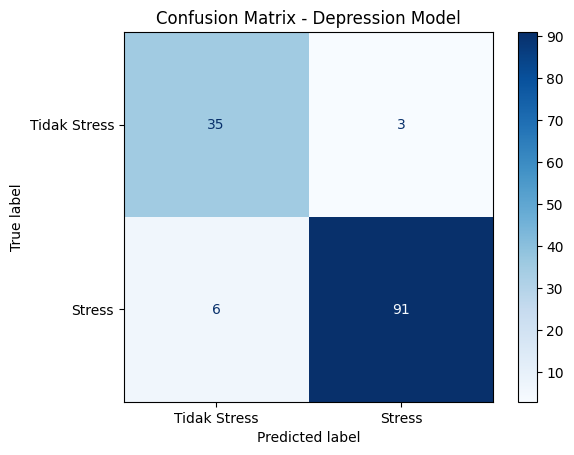

Confusion Matrix:
[[45  4]
 [ 3 83]]

Classification Report:
               precision    recall  f1-score   support

Tidak Anxiety       0.94      0.92      0.93        49
      Anxiety       0.95      0.97      0.96        86

     accuracy                           0.95       135
    macro avg       0.95      0.94      0.94       135
 weighted avg       0.95      0.95      0.95       135



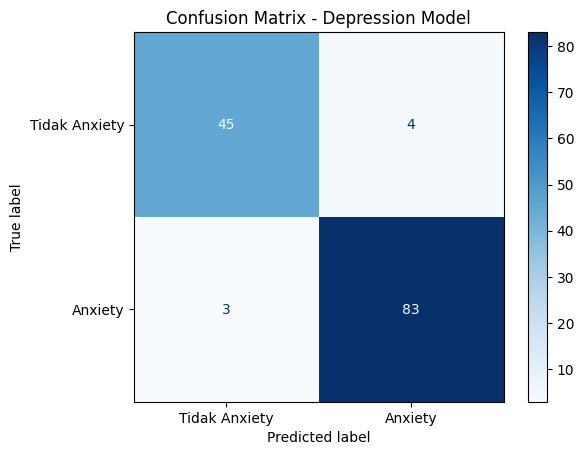

Confusion Matrix:
[[86  3]
 [ 0 46]]

Classification Report:
                  precision    recall  f1-score   support

Tidak Depression       1.00      0.97      0.98        89
      Depression       0.94      1.00      0.97        46

        accuracy                           0.98       135
       macro avg       0.97      0.98      0.98       135
    weighted avg       0.98      0.98      0.98       135



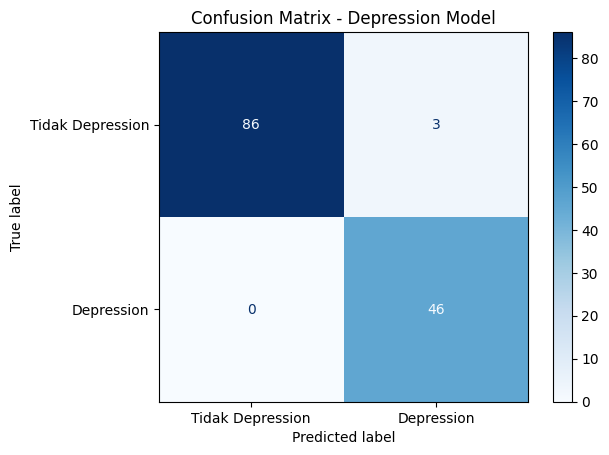

In [49]:
CHECKPOINT_DIR = "binary_relevance_mentalbert_models_oversampling"

for label in LABEL_COLUMNS:
    directory = f"{CHECKPOINT_DIR}/{label.lower()}"
    tokenizer, model = load_binary_classifier(directory)
    test_texts = split_data.test_df["Complaint"].astype(str).tolist()
    y_true = test_targets[label]

    y_pred = []
    
    model.eval()
    for text in test_texts:
        encoded = tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
    
        with torch.no_grad():
            logit = model(**encoded).logits.squeeze().item()
            probability = torch.sigmoid(torch.tensor(logit)).item()
    
        pred = int(probability >= 0.5)
        y_pred.append(pred)
    
    cm = confusion_matrix(y_true, y_pred)
    
    print("Confusion Matrix:")
    print(cm)
    
    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[f"Tidak {label}", label],
        zero_division=0
    ))
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"Tidak {label}", label]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix - Depression Model")
    plt.show()

## 11. Inferensi dengan Bobot Hasil Training

Gunakan folder checkpoint yang dibuat oleh `model.save_pretrained(...)`. Untuk model Depression, path default-nya adalah `binary_relevance_mentalbert_models/depression`.

In [16]:
def load_binary_classifier(checkpoint_dir: str | Path):
    """Load tokenizer dan model biner dari folder hasil training."""

    checkpoint_dir = Path(checkpoint_dir)
    tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir).to(device)
    model.eval()
    return tokenizer, model


def predict_binary_label(
    text: str,
    checkpoint_dir: str | Path,
    threshold: float = 0.5,
    max_length: int = MAX_LENGTH,
) -> Dict[str, float | int]:
    """Prediksi satu label biner dari satu model Binary Relevance."""

    tokenizer, model = load_binary_classifier(checkpoint_dir)
    encoded = tokenizer(
        str(text),
        truncation=True,
        padding="max_length",
        max_length=max_length,
        return_tensors="pt",
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}

    with torch.no_grad():
        logit = model(**encoded).logits.squeeze().item()
        probability = torch.sigmoid(torch.tensor(logit)).item()

    prediction = int(probability >= threshold)
    return {
        "logit": logit,
        "probability": probability,
        "prediction": prediction,
    }

In [43]:
def predict_all_binary_relevance(
    text: str,
    base_checkpoint_dir: str | Path = OUTPUT_DIR,
    threshold: float = 0.5,
) -> Dict[str, Dict[str, float | int]]:
    """Prediksi Stress, Anxiety, dan Depression dari tiga model independen."""

    base_checkpoint_dir = Path(base_checkpoint_dir)
    results = {}

    for label_name in LABEL_COLUMNS:
        checkpoint_dir = base_checkpoint_dir / label_name.lower()
        results[label_name] = predict_binary_label(
            text=text,
            checkpoint_dir=checkpoint_dir,
            threshold=threshold,
        )

    return results

complaint = """	
I've been the most anxious person before I became the most sincere person, I've also been the most worried person before it all ended
"""

all_results = predict_all_binary_relevance(complaint)
for label_name, result in all_results.items():
    status = "YA" if result["prediction"] == 1 else "TIDAK"
    print(f"{label_name:10s}: {status} | probability={result['probability']:.4f}")

Stress    : TIDAK | probability=0.0161
Anxiety   : YA | probability=0.9959
Depression: TIDAK | probability=0.0017
